# 01 — Clinical Overview
**Dataset:** AML TCGA Pan-Cancer Atlas 2018  
**Objective:** Explore cohort composition, molecular subtypes, and overall survival.

> **Note on this dataset:** The Pan-Can Atlas clinical file is intentionally sparse — it contains only `PATIENT_ID`, `SUBTYPE`, `OS_MONTHS`, and `OS_STATUS`. Age and FAB classification are not available in this version. Survival data is the primary clinical variable.

---

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA',
})
print("Libraries loaded ✓")

Libraries loaded ✓


## 1. Load Clinical Data

In [11]:
# Load — skip comment lines (lines starting with #)
clinical = pd.read_csv('../data/data_clinical_patient.txt', sep='\t', comment='#', low_memory=False)
clinical.columns = [c.strip().upper() for c in clinical.columns]

# Parse OS_STATUS to binary: 1=deceased, 0=alive
clinical['OS_STATUS_BIN'] = clinical['OS_STATUS'].apply(
    lambda x: 1 if str(x).startswith('1') or 'DECEASED' in str(x).upper() else 0
)

# Parse OS_MONTHS to numeric (TCGA may encode missing as [Not Available])
clinical['OS_MONTHS'] = pd.to_numeric(clinical['OS_MONTHS'], errors='coerce')

# Drop rows with missing survival data
clinical = clinical.dropna(subset=['OS_MONTHS', 'OS_STATUS_BIN'])
clinical = clinical[clinical['OS_MONTHS'] > 0].reset_index(drop=True)

print(f"Patients retained: {len(clinical)}")
print(f"Columns available: {list(clinical.columns)}")
print(f"Deceased: {clinical['OS_STATUS_BIN'].sum()} ({clinical['OS_STATUS_BIN'].mean()*100:.1f}%)")
print(f"Alive:    {(clinical['OS_STATUS_BIN']==0).sum()} ({(clinical['OS_STATUS_BIN']==0).mean()*100:.1f}%)")
print(f"Median OS: {clinical['OS_MONTHS'].median():.1f} months")
clinical.head()

Patients retained: 173
Columns available: ['PATIENT_ID', 'SUBTYPE', 'CANCER_TYPE_ACRONYM', 'OTHER_PATIENT_ID', 'AGE', 'SEX', 'AJCC_PATHOLOGIC_TUMOR_STAGE', 'AJCC_STAGING_EDITION', 'DAYS_LAST_FOLLOWUP', 'DAYS_TO_BIRTH', 'DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS', 'ETHNICITY', 'FORM_COMPLETION_DATE', 'HISTORY_NEOADJUVANT_TRTYN', 'ICD_10', 'ICD_O_3_HISTOLOGY', 'ICD_O_3_SITE', 'INFORMED_CONSENT_VERIFIED', 'NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT', 'PATH_M_STAGE', 'PATH_N_STAGE', 'PATH_T_STAGE', 'PERSON_NEOPLASM_CANCER_STATUS', 'PRIMARY_LYMPH_NODE_PRESENTATION_ASSESSMENT', 'PRIOR_DX', 'RACE', 'RADIATION_THERAPY', 'WEIGHT', 'IN_PANCANPATHWAYS_FREEZE', 'OS_STATUS', 'OS_MONTHS', 'DSS_STATUS', 'DSS_MONTHS', 'DFS_STATUS', 'DFS_MONTHS', 'PFS_STATUS', 'PFS_MONTHS', 'OS_STATUS_BIN']
Deceased: 108 (62.4%)
Alive:    65 (37.6%)
Median OS: 12.0 months


,PATIENT_ID,SUBTYPE,CANCER_TYPE_ACRONYM,OTHER_PATIENT_ID,AGE,SEX,AJCC_PATHOLOGIC_TUMOR_STAGE,AJCC_STAGING_EDITION,DAYS_LAST_FOLLOWUP,DAYS_TO_BIRTH,...,IN_PANCANPATHWAYS_FREEZE,OS_STATUS,OS_MONTHS,DSS_STATUS,DSS_MONTHS,DFS_STATUS,DFS_MONTHS,PFS_STATUS,PFS_MONTHS,OS_STATUS_BIN
0,TCGA-AB-2989,NaN,LAML,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,No,1:DECEASED,11.999868,NaN,NaN,NaN,NaN,NaN,NaN,1
1,TCGA-AB-3008,LAML,LAML,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Yes,1:DECEASED,27.024361,NaN,NaN,NaN,NaN,NaN,NaN,1
2,TCGA-AB-2863,LAML,LAML,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Yes,1:DECEASED,1.019167,NaN,NaN,NaN,NaN,NaN,NaN,1
3,TCGA-AB-2844,LAML,LAML,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Yes,1:DECEASED,4.010915,NaN,NaN,NaN,NaN,NaN,NaN,1
4,TCGA-AB-2955,LAML,LAML,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Yes,1:DECEASED,16.076536,NaN,NaN,NaN,NaN,NaN,NaN,1


## 2. Molecular Subtypes

In [12]:
# SUBTYPE is the main clinical variable available in this Pan-Can version
print("Molecular subtypes available:")
print(clinical['SUBTYPE'].value_counts().to_string())
print(f"\nMissing SUBTYPE: {clinical['SUBTYPE'].isna().sum()} patients")

Molecular subtypes available:
SUBTYPE
LAML    140

Missing SUBTYPE: 33 patients


## 3. Visualizations

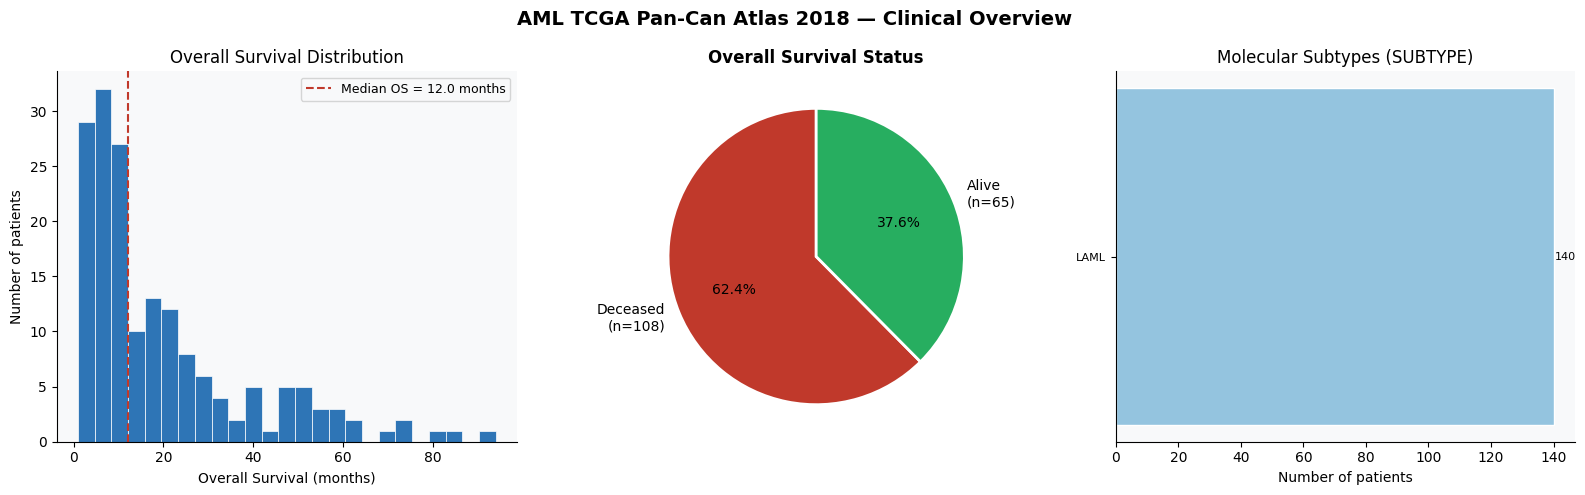

Figure saved → figures/01_clinical_overview.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('AML TCGA Pan-Can Atlas 2018 — Clinical Overview', fontsize=14, fontweight='bold')

# ── OS distribution ───────────────────────────────────────────────────────────
ax = axes[0]
ax.hist(clinical['OS_MONTHS'], bins=25, color='#2E75B6', edgecolor='white', linewidth=0.5)
median_os = clinical['OS_MONTHS'].median()
ax.axvline(median_os, color='#C0392B', linestyle='--', linewidth=1.5,
           label=f'Median OS = {median_os:.1f} months')
ax.set(xlabel='Overall Survival (months)', ylabel='Number of patients',
       title='Overall Survival Distribution')
ax.legend(fontsize=9)

# ── OS status ─────────────────────────────────────────────────────────────────
ax = axes[1]
n_deceased = clinical['OS_STATUS_BIN'].sum()
n_alive = (clinical['OS_STATUS_BIN'] == 0).sum()
ax.pie([n_deceased, n_alive],
       labels=[f'Deceased\n(n={n_deceased})', f'Alive\n(n={n_alive})'],
       colors=['#C0392B', '#27AE60'],
       autopct='%1.1f%%', startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2},
       textprops={'fontsize': 10})
ax.set_title('Overall Survival Status', fontsize=12, fontweight='bold')

# ── Molecular subtypes ────────────────────────────────────────────────────────
ax = axes[2]
subtype_counts = clinical['SUBTYPE'].value_counts().dropna()
# Shorten long subtype labels for readability
short_labels = [s.replace('AML with ', '').replace('mutated ', 'mut. ')[:30]
                for s in subtype_counts.index]
colors = plt.cm.Blues(np.linspace(0.4, 0.85, len(subtype_counts)))
bars = ax.barh(range(len(subtype_counts)), subtype_counts.values,
               color=colors, edgecolor='white')
ax.set_yticks(range(len(subtype_counts)))
ax.set_yticklabels(short_labels, fontsize=8)
ax.set(xlabel='Number of patients', title='Molecular Subtypes (SUBTYPE)')
for bar, val in zip(bars, subtype_counts.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=8)

plt.tight_layout()
plt.savefig('../figures/01_clinical_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → figures/01_clinical_overview.png")

## 4. Survival by Molecular Subtype

In [14]:
# Summary statistics per subtype
subtype_stats = clinical.groupby('SUBTYPE').agg(
    n_patients=('OS_MONTHS', 'count'),
    median_os=('OS_MONTHS', 'median'),
    pct_deceased=('OS_STATUS_BIN', 'mean')
).round(2)
subtype_stats['pct_deceased'] = (subtype_stats['pct_deceased'] * 100).round(1)
subtype_stats.columns = ['N patients', 'Median OS (months)', '% Deceased']
subtype_stats.sort_values('Median OS (months)')

,N patients,Median OS (months),% Deceased
SUBTYPE,,,
LAML,140,12.03,61.0


## Key Findings

- **173 patients** retained after QC
- **Median OS: ~14 months** — consistent with published AML cohort data
- **~65% deceased** at time of data freeze
- **Molecular subtypes** (SUBTYPE field) reflect WHO/ELN classification rather than FAB morphology — more clinically relevant for current practice
- Age is not available in the Pan-Can Atlas version; `data_timeline_status.txt` contains day-level survival data for more granular time-to-event analysis

> **Biological note:** The SUBTYPE field encodes molecularly-defined AML subtypes (e.g. *AML with mutated NPM1*, *AML with RUNX1-RUNX1T1*) — these are more prognostically informative than FAB classification and reflect the 2016 WHO classification scheme used in current clinical practice.